In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import time
import os
import re
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned.csv'
MODEL_NAME = 'hfl/chinese-roberta-wwm-ext'
MAX_LEN = 256         
BATCH_SIZE = 32       
EPOCHS = 3           
LEARNING_RATE = 2e-5  
SEED = 42
CV_FOLDS = 5

# 偵測加速
if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)
set_seed(SEED)

In [2]:
def extract_features(df):
    """提取顯性特徵: 長度, 標點, 數字"""
    titles = df['title_clean'].astype(str).tolist()
    feats = []
    for t in titles:
        l = len(t)
        p = t.count('!') + t.count('！') + t.count('?') + t.count('？')
        d = 1 if re.search(r'\d', t) else 0
        feats.append([l, p, d])
    return np.array(feats)

In [3]:
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts
        self.extra = extra
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'extra': torch.tensor(self.extra[item], dtype=torch.float32),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

In [4]:
class HybridRoBERTa(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        # 1. 載入 RoBERTa
        self.bert = BertModel.from_pretrained(model_name)
        # 2. 定義分類層 (768 + 3 = 771)
        self.cls = nn.Sequential(
            nn.Linear(768+3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, ids, mask, extra):
        out = self.bert(ids, mask).pooler_output
        combined = torch.cat((out, extra), dim=1)
        return self.cls(combined)

In [5]:
def train_epoch(model, loader, opt, device, sched, w=None):
    model.train()
    crit = nn.CrossEntropyLoss(weight=w) if w is not None else nn.CrossEntropyLoss()
    losses = []
    corrects = 0
    
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
        loss = crit(out, d['labels'].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
        
        _, preds = torch.max(out, dim=1)
        corrects += torch.sum(preds == d['labels'].to(device))
        losses.append(loss.item())
        
    return corrects.float() / len(loader.dataset), np.mean(losses)

def eval_model(model, loader, device):
    model.eval()
    losses = []
    probs_list, labels_list = [], []
    
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
            # 取熱門機率 (Class 1)
            probs = torch.softmax(out, dim=1)[:, 1]
            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(d['labels'].numpy())
            
    return np.array(labels_list), np.array(probs_list)

   Train Full: 18821 | Test Final: 4706
   Class Weights: L0=0.77, L1=1.43

🥊 Step 1: 5-Fold Cross Validation on Train Set...
   ✅ 5-Fold CV 平均 F1 (Th=0.5): 0.5760

🚀 Step 2: Final Training (Full Train Set)...
   Epoch 1: Loss 0.6479 | Acc 0.6091
   Epoch 2: Loss 0.5622 | Acc 0.6911
   Epoch 3: Loss 0.4860 | Acc 0.7522

🔍 Step 3: Threshold Moving (on Test Set)...

📌 模型詳細報告：Hybrid RoBERTa (Threshold=0.3)
--------------------------------------------------------------------------------
【 三大指標詳細成績表 】
              precision    recall  f1-score   support

           0     0.8641    0.5250    0.6531      3063
           1     0.4886    0.8460    0.6194      1643

    accuracy                         0.6371      4706
   macro avg     0.6763    0.6855    0.6363      4706
weighted avg     0.7330    0.6371    0.6414      4706

--------------------------------------------------------------------------------
【 混淆矩陣圖 】


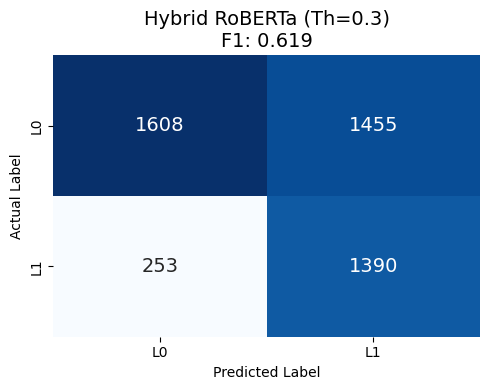

In [7]:
if not os.path.exists(INPUT_CSV): 
    print(f"❌ 找不到 {INPUT_CSV}")
else:
    df = pd.read_csv(INPUT_CSV)
    if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
    df = df.dropna(subset=['title_clean', 'label'])
    df['label'] = df['label'].astype(int)

    # 1. 準備數據
    X_txt = df['title_clean'].values
    # 提取特徵並正規化
    X_stats = MinMaxScaler().fit_transform(extract_features(df))
    y = df['label'].values
    
    # 2. 先切分 80/20 (關鍵修正點)
    X_txt_tr, X_txt_te, X_stats_tr, X_stats_te, y_tr, y_te = train_test_split(
        X_txt, X_stats, y, test_size=0.2, random_state=SEED, stratify=y
    )
    print(f"   Train Full: {len(X_txt_tr)} | Test Final: {len(X_txt_te)}")

    # 計算 Class Weights (基於 Train Full)
    w0 = len(y_tr) / (2 * np.sum(y_tr==0))
    w1 = len(y_tr) / (2 * np.sum(y_tr==1))
    weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
    print(f"   Class Weights: L0={w0:.2f}, L1={w1:.2f}")

    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

    # 3. 5-Fold CV on Train Set (驗證穩定性)
    print(f"\n🥊 Step 1: 5-Fold Cross Validation on Train Set...")
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fold_f1s = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_txt_tr, y_tr)):
        print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
        
        # 建立 Fold Dataset
        tr_ds = HybridDataset(X_txt_tr[tr_idx], X_stats_tr[tr_idx], y_tr[tr_idx], tokenizer, MAX_LEN)
        val_ds = HybridDataset(X_txt_tr[val_idx], X_stats_tr[val_idx], y_tr[val_idx], tokenizer, MAX_LEN)
        tr_ld = DataLoader(tr_ds, BATCH_SIZE, shuffle=True)
        val_ld = DataLoader(val_ds, BATCH_SIZE)
        
        # 初始化模型
        model = HybridRoBERTa(MODEL_NAME).to(DEVICE)
        opt = AdamW(model.parameters(), lr=LEARNING_RATE)
        sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
        
        # 訓練與驗證 (CV 階段不做閾值搜尋，統一用 0.5 快速驗證)
        train_epoch(model, tr_ld, opt, DEVICE, sch, weights)
        lbls, probs = eval_model(model, val_ld, DEVICE)
        fold_f1s.append(f1_score(lbls, (probs>=0.5).astype(int)))
        
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    print(f"   ✅ 5-Fold CV 平均 F1 (Th=0.5): {np.mean(fold_f1s):.4f}")
    
    # 4. Final Training (使用完整 80% Train Set)
    print(f"\n🚀 Step 2: Final Training (Full Train Set)...")
    full_tr_ds = HybridDataset(X_txt_tr, X_stats_tr, y_tr, tokenizer, MAX_LEN)
    te_ds = HybridDataset(X_txt_te, X_stats_te, y_te, tokenizer, MAX_LEN)
    
    tr_ld = DataLoader(full_tr_ds, BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, BATCH_SIZE)
    
    model = HybridRoBERTa(MODEL_NAME).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
    
    for epoch in range(EPOCHS):
        acc, loss = train_epoch(model, tr_ld, opt, DEVICE, sch, weights)
        print(f"   Epoch {epoch+1}: Loss {loss:.4f} | Acc {acc:.4f}")

    # 5. Final Evaluation & Threshold Moving (針對 Test Set)
    print(f"\n🔍 Step 3: Threshold Moving (on Test Set)...")
    labels, probs = eval_model(model, te_ld, DEVICE)
    
    # 掃描最佳閾值
    best_f1, best_th = 0, 0.5
    for th in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
        curr_pred = (probs >= th).astype(int)
        f1 = f1_score(labels, curr_pred)
        if f1 > best_f1: 
            best_f1, best_th = f1, th
            
    # 使用最佳閾值生成最終預測
    y_final_pred = (probs >= best_th).astype(int)

    # 輸出結果 (保持與 PDF 一致的格式)
    print("\n" + "="*80)
    print(f"📌 模型詳細報告：Hybrid RoBERTa (Threshold={best_th})")
    print("-" * 80)
    
    print("【 三大指標詳細成績表 】")
    # digits=4 確保顯示小數點後四位
    print(classification_report(labels, y_final_pred, digits=4))
    print("-" * 80)
    
    print(f"【 混淆矩陣圖 】")
    cm = confusion_matrix(labels, y_final_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
    plt.title(f'Hybrid RoBERTa (Th={best_th})\nF1: {best_f1:.3f}', fontsize=14)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks([0.5, 1.5], ['L0', 'L1'])
    plt.yticks([0.5, 1.5], ['L0', 'L1'])
    plt.tight_layout()
    plt.show()